# Direction D - Temporal split có sanity check

1. Kiểm tra chia theo thời gian: huấn luyện trên năm cũ, kiểm tra trên năm mới.
2. Thêm sanity check để biết kết quả temporal thấp là do mô hình thật sự khó tổng quát theo thời gian hay do lỗi căn hàng dữ liệu.
3. So sánh:
   - `ready_50_features_from_paper`: 50 đặc trưng có sẵn theo từng thuốc.
   - `accessory_gene_chi2_200`: chọn lại 200 gen phụ chỉ trên tập huấn luyện.

In [1]:
# =========================
# 0. Cấu hình
# =========================

import os
import sys
import subprocess
from pathlib import Path

BASE_DIR = Path("/content/salmonella_direction_D_sanity")
REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
OUT_DIR = BASE_DIR / "outputs"
EXTRACT_DIR = BASE_DIR / "extracted"

BASE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

# Random split sanity check.
N_RANDOM_REPEATS = 10

# Số đặc trưng chọn lại từ ma trận gen phụ.
K_ACCESSORY = 200

# Giới hạn số đặc trưng ban đầu để chạy nhẹ hơn.
MAX_VARIANCE_FEATURES = 15000

RANDOM_SEEDS = list(range(N_RANDOM_REPEATS))

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)

BASE_DIR: /content/salmonella_direction_D_sanity
OUT_DIR: /content/salmonella_direction_D_sanity/outputs


In [ ]:

def run_cmd(cmd, check=True):
    print("\n$ " + " ".join(cmd))
    return subprocess.run(cmd, check=check)

run_cmd(["apt-get", "update", "-qq"], check=False)
run_cmd(["apt-get", "install", "-y", "unrar"], check=False)

if not REPO_DIR.exists():
    run_cmd(["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)])
else:
    print("Repo đã tồn tại:", REPO_DIR)

print("\nMột số file/thư mục chính:")
for p in sorted(REPO_DIR.glob("*"))[:30]:
    print("-", p.relative_to(REPO_DIR))


$ apt-get update -qq

$ apt-get install -y unrar

$ git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git /content/salmonella_direction_D_sanity/Antimicrobial-resistance-prediction-in-Salmonella

Một số file/thư mục chính:
- .git
- README.md
- code
- data
- results


In [ ]:

import re
import json
import math
import zipfile
import warnings
from collections import defaultdict, Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

In [ ]:

def make_sample_index(n):
    return pd.Index([f"sample_{i}" for i in range(n)], name="sample_id")


def clean_colname(c):
    return str(c).strip()


def read_csv_flexible(path):
    path = Path(path)
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_csv(path, sep="\t")


def find_year_column(df):
    for c in df.columns:
        if "year" in str(c).lower():
            return c
    return None


def detect_label_column(df, drug):
    if df.shape[1] == 1:
        return df.columns[0]
    for c in df.columns:
        lc = str(c).lower()
        if drug.lower() in lc and ("label" in lc or "concl" in lc or "res" in lc):
            return c
    for c in df.columns:
        lc = str(c).lower()
        if "label" in lc or "concl" in lc or "res" in lc:
            return c
    return df.columns[-1]


def normalize_binary_label(s):
    s = s.copy()
    if s.dtype == object:
        s2 = s.astype(str).str.strip()
        mapping = {
            "R": 1, "r": 1, "Resistant": 1, "resistant": 1, "Resistance": 1,
            "S": 0, "s": 0, "Susceptible": 0, "susceptible": 0,
            "I": 0, "i": 0, "Intermediate": 0, "intermediate": 0,
            "0": 0, "1": 1,
        }
        return s2.map(mapping)
    return pd.to_numeric(s, errors="coerce")


def to_numeric_feature_df(df):
    df = df.copy()
    drop_cols = []
    for c in list(df.columns):
        if df[c].dtype == object:
            converted = pd.to_numeric(df[c], errors="coerce")
            if converted.notna().mean() > 0.95:
                df[c] = converted.fillna(0)
            else:
                drop_cols.append(c)
    if drop_cols:
        df = df.drop(columns=drop_cols)
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return df.astype(np.float32)


def compute_metrics(y_true, pred, prob):
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
    }
    try:
        out["auroc"] = roc_auc_score(y_true, prob)
    except Exception:
        out["auroc"] = np.nan
    try:
        out["auprc"] = average_precision_score(y_true, prob)
    except Exception:
        out["auprc"] = np.nan
    return out


def build_lr_model(random_state=42):
    return Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(
            max_iter=10000,
            class_weight="balanced",
            solver="liblinear",
            random_state=random_state
        ))
    ])


def train_eval_lr(X_train, y_train, X_test, y_test, random_state=42):
    model = build_lr_model(random_state=random_state)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    metrics = compute_metrics(y_test, pred, prob)
    cm = confusion_matrix(y_test, pred, labels=[0, 1])
    return metrics, pred, prob, cm, model


def select_chi2_train_only(X_train, y_train, X_test, k=200):
    X_train_nonneg = X_train.copy()
    X_test_nonneg = X_test.copy()
    X_train_nonneg[X_train_nonneg < 0] = 0
    X_test_nonneg[X_test_nonneg < 0] = 0

    k = min(k, X_train_nonneg.shape[1])
    selector = SelectKBest(score_func=chi2, k=k)
    selector.fit(X_train_nonneg, y_train)
    cols = X_train_nonneg.columns[selector.get_support()].tolist()
    return X_train_nonneg[cols], X_test_nonneg[cols], cols

In [ ]:
# =========================
# 4. Đọc metadata / nhãn / năm
# =========================

label_path = REPO_DIR / "data" / "data acquisition" / "Salmonella_resistance_data_samples.csv"
labels_meta = read_csv_flexible(label_path)
labels_meta.columns = [clean_colname(c) for c in labels_meta.columns]

print("Metadata shape:", labels_meta.shape)
display(labels_meta.head())

labels_meta.index = make_sample_index(len(labels_meta))

YEAR_COL = find_year_column(labels_meta)
print("YEAR_COL:", YEAR_COL)
if YEAR_COL is None:
    raise ValueError("Không tìm thấy cột năm trong metadata.")

labels_meta["year_numeric"] = pd.to_numeric(labels_meta[YEAR_COL], errors="coerce")

print("Số mẫu thiếu năm:", labels_meta["year_numeric"].isna().sum())
print("Phân bố năm:")
display(labels_meta["year_numeric"].value_counts(dropna=False).sort_index())

Metadata shape: (1167, 27)


,Specimen ID,NCBI Accession Number,WGS ID,AST Approved,WGS Approved,Genus,Species,Serotype,Data Year,Region Name,Resistance Pattern,Resistance Determinants,Predictive Resistance Pattern,AMP Rslt,AMP Concl,AUG Rslt,AUG Concl,AXO Rslt,AXO Concl,CHL Rslt,CHL Concl,FIS Rslt,FIS Concl,FOX Rslt,FOX Concl,TET Rslt,TET Concl
0,2015AM-0015,SAMN07268531,2015AM-0015,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 5,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,8,S,16,S,2,S,4,S
1,2015AM-0056,SAMN07418885,2015AM-0056,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 3,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,4,S,16,S,2,S,4,S
2,2015AM-0082,SAMN07286125,2015AM-0082,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 8,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,4,S,16,S,2,S,4,S
3,2015AM-0081,SAMN07286124,2015AM-0081,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 8,No resistance detected,No determinants detected,No determinants detected,1,S,1,S,0.25,S,4,S,32,S,2,S,4,S
4,2015AM-0097,SAMN07281088,2015AM-0097,yes,yes,Salmonella,enterica,Typhimurium,2015,Region 5,AAuCxTioFox,blaCMY-2,AAuCxTioFox,32,R,32,R,32.00,R,4,S,16,S,32,R,4,S


YEAR_COL: Data Year
Số mẫu thiếu năm: 430
Phân bố năm:


,count
year_numeric,
2015.0,217
2016.0,237
2017.0,118
2018.0,165
NaN,430


In [6]:
# =========================
# 5. Load ready 50 features theo từng thuốc
# =========================

def load_ready_drug(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    X_path = drug_dir / "gene.csv"
    y_path = drug_dir / f"{drug}_label.csv"

    X = read_csv_flexible(X_path)
    ydf = read_csv_flexible(y_path)

    X = to_numeric_feature_df(X)
    X.index = make_sample_index(len(X))

    label_col = detect_label_column(ydf, drug)
    y = normalize_binary_label(ydf[label_col])
    y.index = make_sample_index(len(y))

    ok = y.notna()
    X = X.loc[ok]
    y = y.loc[ok].astype(int)
    return X, y

ready_data = {}
for drug in DRUGS:
    X, y = load_ready_drug(drug)
    ready_data[drug] = (X, y)
    print(drug, "X:", X.shape, "y:", y.shape, "resistant:", int(y.sum()), f"({y.mean()*100:.1f}%)")

AMP X: (1167, 50) y: (1167,) resistant: 199 (17.1%)
AUG X: (1167, 50) y: (1167,) resistant: 139 (11.9%)
AXO X: (1167, 50) y: (1167,) resistant: 71 (6.1%)
CHL X: (1167, 50) y: (1167,) resistant: 126 (10.8%)
FOX X: (1167, 50) y: (1167,) resistant: 71 (6.1%)


In [7]:
# =========================
# 6. Kiểm tra khớp nhãn giữa ready label và metadata
# =========================

check_rows = []
for drug in DRUGS:
    X_ready, y_ready = ready_data[drug]
    possible_cols = []
    for c in labels_meta.columns:
        lc = str(c).lower()
        if drug.lower() in lc and ("concl" in lc or "label" in lc or "res" in lc):
            possible_cols.append(c)

    if possible_cols:
        c = possible_cols[0]
        y_meta = normalize_binary_label(labels_meta.loc[y_ready.index, c])
        valid = y_meta.notna() & y_ready.notna()
        agreement = (y_meta.loc[valid].astype(int) == y_ready.loc[valid].astype(int)).mean() if valid.sum() else np.nan
        check_rows.append({
            "drug": drug,
            "metadata_label_col": c,
            "n_checked": int(valid.sum()),
            "agreement_ready_vs_metadata": agreement,
        })
    else:
        check_rows.append({
            "drug": drug,
            "metadata_label_col": None,
            "n_checked": 0,
            "agreement_ready_vs_metadata": np.nan,
        })

label_check_df = pd.DataFrame(check_rows)
display(label_check_df)
label_check_df.to_csv(OUT_DIR / "label_alignment_check.csv", index=False)

print("Nếu agreement gần 1.0 thì thứ tự sample giữa metadata và data/csv nhiều khả năng đúng.")

,drug,metadata_label_col,n_checked,agreement_ready_vs_metadata
0,AMP,AMP Concl,1167,0.717224
1,AUG,AUG Concl,1167,0.826907
2,AXO,AXO Concl,1167,0.881748
3,CHL,CHL Concl,1167,0.807198
4,FOX,FOX Concl,1167,0.888603


Nếu agreement gần 1.0 thì thứ tự sample giữa metadata và data/csv nhiều khả năng đúng.


In [8]:
# =========================
# 7. Load ma trận gen phụ đầy đủ
# =========================

def extract_rar_if_needed(rar_path, out_folder):
    rar_path = Path(rar_path)
    out_folder = Path(out_folder)
    out_folder.mkdir(parents=True, exist_ok=True)
    existing_tables = list(out_folder.rglob("*.csv")) + list(out_folder.rglob("*.tsv")) + list(out_folder.rglob("*.txt"))
    if existing_tables:
        print("Đã có file giải nén trong:", out_folder)
        return
    print("Giải nén:", rar_path)
    run_cmd(["unrar", "x", "-o+", str(rar_path), str(out_folder)], check=False)

accessory_rar = REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar"
accessory_extract = EXTRACT_DIR / "accessory_gene"
extract_rar_if_needed(accessory_rar, accessory_extract)

tables = list(accessory_extract.rglob("*.csv")) + list(accessory_extract.rglob("*.tsv")) + list(accessory_extract.rglob("*.txt"))
print("Bảng tìm thấy:")
for p in tables:
    print("-", p, p.stat().st_size / 1e6, "MB")

if not tables:
    raise FileNotFoundError("Không tìm thấy bảng accessory gene sau giải nén.")

# chọn file lớn nhất
accessory_path = max(tables, key=lambda p: p.stat().st_size)
print("Đọc accessory:", accessory_path)

X_accessory_raw = read_csv_flexible(accessory_path)
print("Raw accessory shape:", X_accessory_raw.shape)

X_accessory = to_numeric_feature_df(X_accessory_raw)

# Nếu số hàng bằng số metadata, gán sample_id theo thứ tự.
if X_accessory.shape[0] == len(labels_meta):
    X_accessory.index = labels_meta.index
else:
    print("CẢNH BÁO: số hàng accessory không bằng metadata.")
    print("X_accessory.shape:", X_accessory.shape, "metadata:", len(labels_meta))

print("Accessory numeric shape:", X_accessory.shape)
display(X_accessory.head())

Giải nén: /content/salmonella_direction_D_sanity/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar

$ unrar x -o+ /content/salmonella_direction_D_sanity/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar /content/salmonella_direction_D_sanity/extracted/accessory_gene
Bảng tìm thấy:
- /content/salmonella_direction_D_sanity/extracted/accessory_gene/accessory gene existence matrix.csv 42.556799 MB
Đọc accessory: /content/salmonella_direction_D_sanity/extracted/accessory_gene/accessory gene existence matrix.csv
Raw accessory shape: (1167, 18126)
Accessory numeric shape: (1167, 18125)


,ldtD,golT,GXP82_000609,D1K42_06100,astB,rcsC,CP786_19315,trpL,nsrR,CE641_06520,priB,atpB,C2K48_18010,glmU,GPC98_001636,pepD,KDM75_001078,mnmG,GPQ64_004095,recG,pspE,rnr,rbsC,CEZ51_03995,GPA53_001343,K6M88_000542,ulaC,GV878_10160,radC,pyrL,GTT10_000474,rpmG,tyrR,mntS,ogt,GNM13_02880,EGD39_01585,bsmA,guaB,spoT,GXF62_03920,group_19145,rbsD,yciH,lpcA,C3Z62_00515,pyrI,cpdB,DX213_00020,pstB,...,CIH76_24580,CFE76_24980,GY309_005113,CIH76_24590,GY309_005114,GVB88_004872,K1191_004981,M8W61_004960,E3K79_24685,E3K79_24675,aac(3)-IId,group_9830,group_9831,group_9832,group_9834,group_9835,GVB81_004985,GXR61_005002,E6U56_24000,GVC77_004899,CEW36_25740,GWJ30_24850,E5721_03835,E5721_03840,GSC72_004744,E5721_03890,E5721_04000,E6B36_14780,E3K74_23715,E3V06_02760,K3K99_004871,IQT32_004913,NJA97_004922,DQ665_27120,group_9873,IYQ21_004865,K3K99_004875,DSC76_25825,I3040_005055,CP786_24040,D5S55_04420,EOH01_20505,EOH01_23295,EOH01_24105,CFJ60_24800,DCH97_24375,CIX89_24825,D6I09_24665,D6I09_24690,D6I09_24695
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
sample_0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
sample_4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
# =========================
# 8. Giảm chiều sơ bộ theo phương sai cho accessory
# =========================

# Giảm chiều để chạy nhanh hơn, nhưng selector chi-square chính vẫn chỉ fit trên train.
if X_accessory.shape[1] > MAX_VARIANCE_FEATURES:
    print(f"Giảm từ {X_accessory.shape[1]} xuống top {MAX_VARIANCE_FEATURES} feature theo phương sai.")
    variances = X_accessory.var(axis=0)
    top_cols = variances.sort_values(ascending=False).head(MAX_VARIANCE_FEATURES).index.tolist()
    X_accessory_reduced = X_accessory[top_cols].copy()
else:
    X_accessory_reduced = X_accessory.copy()

print("Accessory reduced shape:", X_accessory_reduced.shape)

Giảm từ 18125 xuống top 15000 feature theo phương sai.
Accessory reduced shape: (1167, 15000)


In [10]:
# =========================
# 9. Hàm đánh giá random split và temporal split
# =========================

def get_year_filtered_index(y):
    idx = y.index.intersection(labels_meta.index)
    year = labels_meta.loc[idx, "year_numeric"]
    ok = year.notna()
    return idx[ok], year.loc[ok].astype(int)


def random_repeated_eval(X, y, setting, drug, n_repeats=N_RANDOM_REPEATS, test_size=0.2):
    rows = []
    for seed in RANDOM_SEEDS[:n_repeats]:
        if y.nunique() < 2:
            continue
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )
        metrics, pred, prob, cm, model = train_eval_lr(X_train, y_train, X_test, y_test, random_state=seed)
        rows.append({
            "drug": drug,
            "setting": setting,
            "split_type": "random_repeated",
            "seed": seed,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            **metrics
        })
    return pd.DataFrame(rows)


def random_repeated_eval_accessory_chi2(X, y, drug, k=200, n_repeats=N_RANDOM_REPEATS, test_size=0.2):
    rows = []
    for seed in RANDOM_SEEDS[:n_repeats]:
        if y.nunique() < 2:
            continue
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=test_size,
            random_state=seed,
            stratify=y
        )
        Xtr_sel, Xte_sel, cols = select_chi2_train_only(X_train, y_train, X_test, k=k)
        metrics, pred, prob, cm, model = train_eval_lr(Xtr_sel, y_train, Xte_sel, y_test, random_state=seed)
        rows.append({
            "drug": drug,
            "setting": f"accessory_train_only_chi2_{k}",
            "split_type": "random_repeated",
            "seed": seed,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "k_features": k,
            **metrics
        })
    return pd.DataFrame(rows)


def choose_temporal_cutoff(years, y, min_test_pos=5, min_train_pos=5, min_test_n=30):
    # Train <= cutoff, test > cutoff.
    unique_years = sorted(years.dropna().astype(int).unique())
    candidates = []
    for cutoff in unique_years[:-1]:
        train_idx = years.index[years <= cutoff]
        test_idx = years.index[years > cutoff]
        if len(test_idx) < min_test_n:
            continue
        y_train = y.loc[train_idx]
        y_test = y.loc[test_idx]
        if y_train.nunique() < 2 or y_test.nunique() < 2:
            continue
        if y_train.sum() < min_train_pos or y_test.sum() < min_test_pos:
            continue
        candidates.append({
            "cutoff": cutoff,
            "train_year_min": int(years.loc[train_idx].min()),
            "train_year_max": int(years.loc[train_idx].max()),
            "test_year_min": int(years.loc[test_idx].min()),
            "test_year_max": int(years.loc[test_idx].max()),
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "train_pos": int(y_train.sum()),
            "test_pos": int(y_test.sum()),
            "train_idx": train_idx,
            "test_idx": test_idx,
        })
    if not candidates:
        return None
    # Chọn cutoff có test set mới nhất nhưng vẫn đủ mẫu.
    return candidates[-1]


def temporal_eval_ready(X, y, drug):
    idx_year, years = get_year_filtered_index(y)
    X_use = X.loc[idx_year]
    y_use = y.loc[idx_year]
    years_use = years.loc[idx_year]

    best = choose_temporal_cutoff(years_use, y_use)
    if best is None:
        return None, None

    train_idx = best["train_idx"]
    test_idx = best["test_idx"]

    X_train = X_use.loc[train_idx]
    X_test = X_use.loc[test_idx]
    y_train = y_use.loc[train_idx]
    y_test = y_use.loc[test_idx]

    metrics, pred, prob, cm, model = train_eval_lr(X_train, y_train, X_test, y_test)

    row = {
        "drug": drug,
        "setting": "ready_50_features_from_paper",
        "split_type": "temporal",
        **{k:v for k,v in best.items() if k not in ["train_idx", "test_idx"]},
        **metrics
    }
    pred_pack = {"y_test": y_test, "pred": pred, "prob": prob, "cm": cm, "years_test": years_use.loc[test_idx]}
    return row, pred_pack


def temporal_eval_accessory_chi2(X, y, drug, k=200):
    idx_year, years = get_year_filtered_index(y)
    X_use = X.loc[idx_year]
    y_use = y.loc[idx_year]
    years_use = years.loc[idx_year]

    best = choose_temporal_cutoff(years_use, y_use)
    if best is None:
        return None, None, None

    train_idx = best["train_idx"]
    test_idx = best["test_idx"]

    X_train = X_use.loc[train_idx]
    X_test = X_use.loc[test_idx]
    y_train = y_use.loc[train_idx]
    y_test = y_use.loc[test_idx]

    Xtr_sel, Xte_sel, cols = select_chi2_train_only(X_train, y_train, X_test, k=k)
    metrics, pred, prob, cm, model = train_eval_lr(Xtr_sel, y_train, Xte_sel, y_test)

    row = {
        "drug": drug,
        "setting": f"accessory_train_only_chi2_{k}",
        "split_type": "temporal",
        **{k2:v for k2,v in best.items() if k2 not in ["train_idx", "test_idx"]},
        "k_features": k,
        **metrics
    }
    pred_pack = {"y_test": y_test, "pred": pred, "prob": prob, "cm": cm, "years_test": years_use.loc[test_idx]}
    return row, pred_pack, cols

In [11]:
# =========================
# 10. Sanity check: ready 50 trên toàn bộ dữ liệu và trên tập có năm
# =========================

random_rows = []
random_year_rows = []

for drug in DRUGS:
    X_ready, y = ready_data[drug]

    # Random trên toàn bộ 1167 mẫu.
    df_all = random_repeated_eval(X_ready, y, "ready_50_features_from_paper", drug, n_repeats=N_RANDOM_REPEATS)
    random_rows.append(df_all)

    # Random chỉ trên mẫu có năm.
    idx_year, years = get_year_filtered_index(y)
    X_year = X_ready.loc[idx_year]
    y_year = y.loc[idx_year]
    df_year = random_repeated_eval(X_year, y_year, "ready_50_features_from_paper_year_subset", drug, n_repeats=N_RANDOM_REPEATS)
    random_year_rows.append(df_year)

ready_random_all_df = pd.concat(random_rows, ignore_index=True)
ready_random_year_df = pd.concat(random_year_rows, ignore_index=True)

ready_random_all_summary = ready_random_all_df.groupby(["drug", "setting"])[["balanced_accuracy", "f1", "auroc", "auprc"]].agg(["mean", "std"]).reset_index()
ready_random_year_summary = ready_random_year_df.groupby(["drug", "setting"])[["balanced_accuracy", "f1", "auroc", "auprc"]].agg(["mean", "std"]).reset_index()

print("Random split với ready 50 features trên toàn bộ dữ liệu:")
display(ready_random_all_summary)

print("Random split với ready 50 features chỉ trên mẫu có năm:")
display(ready_random_year_summary)

ready_random_all_df.to_csv(OUT_DIR / "ready50_random_all_repeats.csv", index=False)
ready_random_year_df.to_csv(OUT_DIR / "ready50_random_year_subset_repeats.csv", index=False)

Random split với ready 50 features trên toàn bộ dữ liệu:


drug                       setting balanced_accuracy                  f1               auroc               auprc          
                                                  mean       std      mean       std      mean       std      mean       std
0  AMP  ready_50_features_from_paper          0.948995  0.010006  0.916550  0.023730  0.968054  0.013577  0.941599  0.014979
1  AUG  ready_50_features_from_paper          0.962361  0.019441  0.918093  0.030580  0.982264  0.012985  0.937280  0.034990
2  AXO  ready_50_features_from_paper          0.981461  0.025099  0.970861  0.029155  0.999448  0.000553  0.992111  0.007941
3  CHL  ready_50_features_from_paper          0.927234  0.032789  0.853842  0.057414  0.924469  0.047314  0.900308  0.054573
4  FOX  ready_50_features_from_paper          0.952435  0.037010  0.932621  0.031865  0.982614  0.021968  0.947939  0.040136

Random split với ready 50 features chỉ trên mẫu có năm:


drug                                   setting balanced_accuracy                  f1               auroc               auprc          
                                                              mean       std      mean       std      mean       std      mean       std
0  AMP  ready_50_features_from_paper_year_subset          0.936424  0.019078  0.908349  0.021782  0.962721  0.014379  0.932492  0.023784
1  AUG  ready_50_features_from_paper_year_subset          0.961016  0.025343  0.914529  0.029967  0.981211  0.023164  0.936815  0.049009
2  AXO  ready_50_features_from_paper_year_subset          0.979638  0.025532  0.974185  0.027252  0.999783  0.000489  0.997424  0.005716
3  CHL  ready_50_features_from_paper_year_subset          0.938376  0.028072  0.884941  0.036000  0.938162  0.050086  0.921441  0.052368
4  FOX  ready_50_features_from_paper_year_subset          0.974275  0.035388  0.963601  0.043339  0.997681  0.003797  0.981803  0.027385

In [12]:
# =========================
# 11. Sanity check: accessory chi2 200 random trên tập có năm
# =========================

accessory_random_year_rows = []

for drug in DRUGS:
    _, y = ready_data[drug]
    idx_year, years = get_year_filtered_index(y)
    common_idx = X_accessory_reduced.index.intersection(idx_year)

    X_year = X_accessory_reduced.loc[common_idx]
    y_year = y.loc[common_idx]

    df = random_repeated_eval_accessory_chi2(
        X_year,
        y_year,
        drug=drug,
        k=K_ACCESSORY,
        n_repeats=N_RANDOM_REPEATS
    )
    accessory_random_year_rows.append(df)

accessory_random_year_df = pd.concat(accessory_random_year_rows, ignore_index=True)
accessory_random_year_summary = accessory_random_year_df.groupby(["drug", "setting"])[["balanced_accuracy", "f1", "auroc", "auprc"]].agg(["mean", "std"]).reset_index()

print("Random split với accessory chi2 200 trên mẫu có năm:")
display(accessory_random_year_summary)

accessory_random_year_df.to_csv(OUT_DIR / "accessory_chi2_random_year_subset_repeats.csv", index=False)

Random split với accessory chi2 200 trên mẫu có năm:


drug                        setting balanced_accuracy                  f1               auroc               auprc          
                                                   mean       std      mean       std      mean       std      mean       std
0  AMP  accessory_train_only_chi2_200          0.895726  0.030970  0.837734  0.044739  0.934584  0.025888  0.887007  0.041025
1  AUG  accessory_train_only_chi2_200          0.970859  0.033193  0.936076  0.052533  0.972500  0.037131  0.951436  0.058503
2  AXO  accessory_train_only_chi2_200          0.980000  0.025820  0.978947  0.027179  0.981304  0.024143  0.962926  0.047862
3  CHL  accessory_train_only_chi2_200          0.930342  0.031391  0.891237  0.034953  0.937158  0.049496  0.896114  0.061801
4  FOX  accessory_train_only_chi2_200          0.979638  0.025532  0.974185  0.027252  0.981775  0.023545  0.962955  0.047825

In [13]:
# =========================
# 12. Temporal split: ready 50 và accessory chi2 200
# =========================

temporal_rows = []
temporal_pred_packs = {}
temporal_selected = {}

for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy temporal:", drug)
    print("="*80)

    X_ready, y = ready_data[drug]

    # Ready 50 temporal.
    row_ready, pack_ready = temporal_eval_ready(X_ready, y, drug)
    if row_ready is not None:
        temporal_rows.append(row_ready)
        temporal_pred_packs[(drug, "ready_50_features_from_paper")] = pack_ready
        print("Ready temporal:", row_ready)
    else:
        print("Không tìm được temporal split phù hợp cho ready:", drug)

    # Accessory chi2 temporal.
    common_idx = X_accessory_reduced.index.intersection(y.index)
    X_acc = X_accessory_reduced.loc[common_idx]
    y_acc = y.loc[common_idx]

    row_acc, pack_acc, cols_acc = temporal_eval_accessory_chi2(X_acc, y_acc, drug, k=K_ACCESSORY)
    if row_acc is not None:
        temporal_rows.append(row_acc)
        temporal_pred_packs[(drug, f"accessory_train_only_chi2_{K_ACCESSORY}")] = pack_acc
        temporal_selected[drug] = cols_acc
        print("Accessory temporal:", row_acc)
    else:
        print("Không tìm được temporal split phù hợp cho accessory:", drug)

temporal_df = pd.DataFrame(temporal_rows)
display(temporal_df)

temporal_df.to_csv(OUT_DIR / "temporal_results_ready50_vs_accessory_chi2.csv", index=False)


Đang chạy temporal: AMP
Ready temporal: {'drug': 'AMP', 'setting': 'ready_50_features_from_paper', 'split_type': 'temporal', 'cutoff': np.int64(2017), 'train_year_min': 2015, 'train_year_max': 2017, 'test_year_min': 2018, 'test_year_max': 2018, 'n_train': 572, 'n_test': 165, 'train_pos': 106, 'test_pos': 38, 'accuracy': 0.9333333333333333, 'balanced_accuracy': np.float64(0.8921467053460422), 'f1': 0.8493150684931506, 'auroc': np.float64(0.9321384169084128), 'auprc': np.float64(0.8933465120553934)}
Accessory temporal: {'drug': 'AMP', 'setting': 'accessory_train_only_chi2_200', 'split_type': 'temporal', 'cutoff': np.int64(2017), 'train_year_min': 2015, 'train_year_max': 2017, 'test_year_min': 2018, 'test_year_max': 2018, 'n_train': 572, 'n_test': 165, 'train_pos': 106, 'test_pos': 38, 'k_features': 200, 'accuracy': 0.9212121212121213, 'balanced_accuracy': np.float64(0.8842726895980108), 'f1': 0.8266666666666667, 'auroc': np.float64(0.9087235806050559), 'auprc': np.float64(0.845529765949

,drug,setting,split_type,cutoff,train_year_min,train_year_max,test_year_min,test_year_max,n_train,n_test,train_pos,test_pos,accuracy,balanced_accuracy,f1,auroc,auprc,k_features
0,AMP,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,106,38,0.933333,0.892147,0.849315,0.932138,0.893347,NaN
1,AMP,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,106,38,0.921212,0.884273,0.826667,0.908724,0.845530,200.0
2,AUG,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,76,23,0.969697,0.909522,0.883721,0.938763,0.869309,NaN
3,AUG,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,76,23,0.969697,0.909522,0.883721,0.913962,0.845539,200.0
4,AXO,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,40,12,0.993939,0.958333,0.956522,1.000000,1.000000,NaN
5,AXO,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,40,12,0.993939,0.958333,0.956522,0.959967,0.923118,200.0
6,CHL,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,67,21,0.957576,0.853671,0.810811,0.828538,0.777992,NaN
7,CHL,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,67,21,0.957576,0.833333,0.800000,0.825728,0.752827,200.0
8,FOX,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,39,11,0.993939,0.954545,0.952381,0.987603,0.940341,NaN
9,FOX,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,39,11,0.993939,0.954545,0.952381,0.957792,0.915670,200.0


In [14]:
# =========================
# 13. So sánh temporal với random year subset
# =========================

# Gom random summary thành format phẳng.
def flatten_summary(summary_df):
    out = summary_df.copy()
    out.columns = ["_".join([str(x) for x in col if str(x) != ""]) for col in out.columns.to_flat_index()]
    return out

ready_year_flat = flatten_summary(ready_random_year_summary)
accessory_year_flat = flatten_summary(accessory_random_year_summary)

ready_year_flat = ready_year_flat.rename(columns={
    "balanced_accuracy_mean": "random_balanced_accuracy_mean",
    "balanced_accuracy_std": "random_balanced_accuracy_std",
    "auprc_mean": "random_auprc_mean",
    "auprc_std": "random_auprc_std",
})
accessory_year_flat = accessory_year_flat.rename(columns={
    "balanced_accuracy_mean": "random_balanced_accuracy_mean",
    "balanced_accuracy_std": "random_balanced_accuracy_std",
    "auprc_mean": "random_auprc_mean",
    "auprc_std": "random_auprc_std",
})

random_flat = pd.concat([
    ready_year_flat[["drug", "setting", "random_balanced_accuracy_mean", "random_balanced_accuracy_std", "random_auprc_mean", "random_auprc_std"]],
    accessory_year_flat[["drug", "setting", "random_balanced_accuracy_mean", "random_balanced_accuracy_std", "random_auprc_mean", "random_auprc_std"]],
], ignore_index=True)

comparison_df = temporal_df.merge(random_flat, on=["drug", "setting"], how="left")
comparison_df["delta_temporal_minus_random_balacc"] = comparison_df["balanced_accuracy"] - comparison_df["random_balanced_accuracy_mean"]
comparison_df["delta_temporal_minus_random_auprc"] = comparison_df["auprc"] - comparison_df["random_auprc_mean"]

display(comparison_df)
comparison_df.to_csv(OUT_DIR / "temporal_vs_random_year_subset_comparison.csv", index=False)

,drug,setting,split_type,cutoff,train_year_min,train_year_max,test_year_min,test_year_max,n_train,n_test,train_pos,test_pos,accuracy,balanced_accuracy,f1,auroc,auprc,k_features,random_balanced_accuracy_mean,random_balanced_accuracy_std,random_auprc_mean,random_auprc_std,delta_temporal_minus_random_balacc,delta_temporal_minus_random_auprc
0,AMP,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,106,38,0.933333,0.892147,0.849315,0.932138,0.893347,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMP,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,106,38,0.921212,0.884273,0.826667,0.908724,0.845530,200.0,0.895726,0.030970,0.887007,0.041025,-0.011453,-0.041478
2,AUG,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,76,23,0.969697,0.909522,0.883721,0.938763,0.869309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AUG,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,76,23,0.969697,0.909522,0.883721,0.913962,0.845539,200.0,0.970859,0.033193,0.951436,0.058503,-0.061337,-0.105896
4,AXO,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,40,12,0.993939,0.958333,0.956522,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,AXO,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,40,12,0.993939,0.958333,0.956522,0.959967,0.923118,200.0,0.980000,0.025820,0.962926,0.047862,-0.021667,-0.039808
6,CHL,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,67,21,0.957576,0.853671,0.810811,0.828538,0.777992,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CHL,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,67,21,0.957576,0.833333,0.800000,0.825728,0.752827,200.0,0.930342,0.031391,0.896114,0.061801,-0.097009,-0.143286
8,FOX,ready_50_features_from_paper,temporal,2017,2015,2017,2018,2018,572,165,39,11,0.993939,0.954545,0.952381,0.987603,0.940341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,FOX,accessory_train_only_chi2_200,temporal,2017,2015,2017,2018,2018,572,165,39,11,0.993939,0.954545,0.952381,0.957792,0.915670,200.0,0.979638,0.025532,0.962955,0.047825,-0.025092,-0.047285


,drug,year,n,n_resistant,resistant_rate
0,AMP,2015,217,48,0.221198
1,AMP,2016,237,37,0.156118
2,AMP,2017,118,21,0.177966
3,AMP,2018,165,38,0.230303
4,AUG,2015,217,34,0.156682
5,AUG,2016,237,28,0.118143
6,AUG,2017,118,14,0.118644
7,AUG,2018,165,23,0.139394
8,AXO,2015,217,21,0.096774
9,AXO,2016,237,13,0.054852


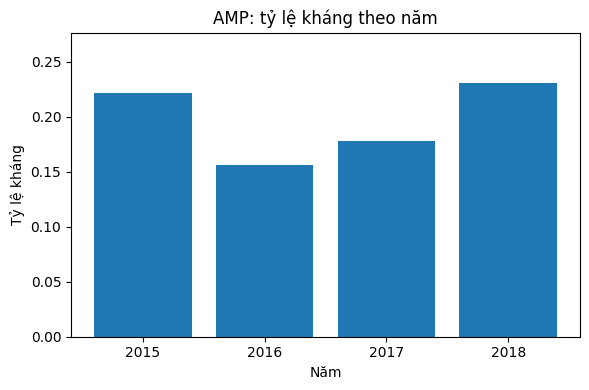

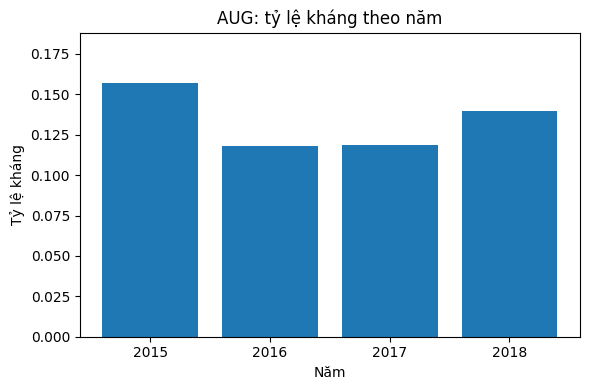

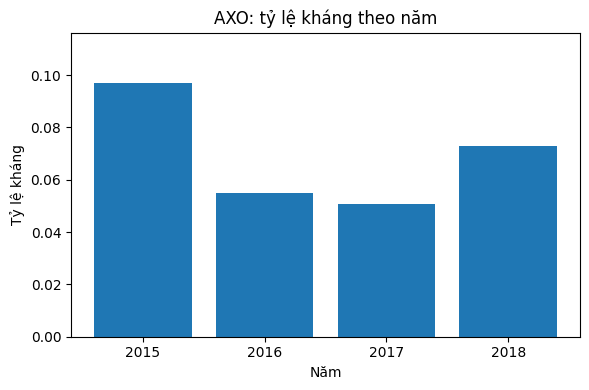

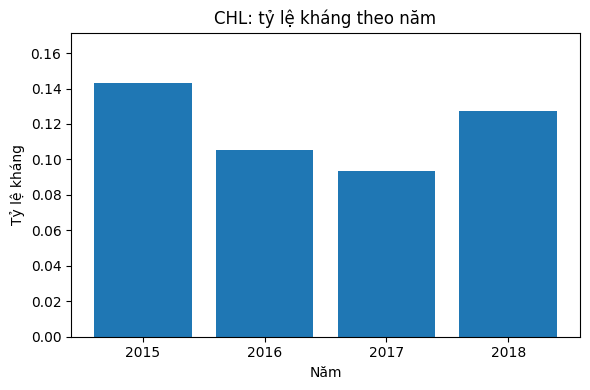

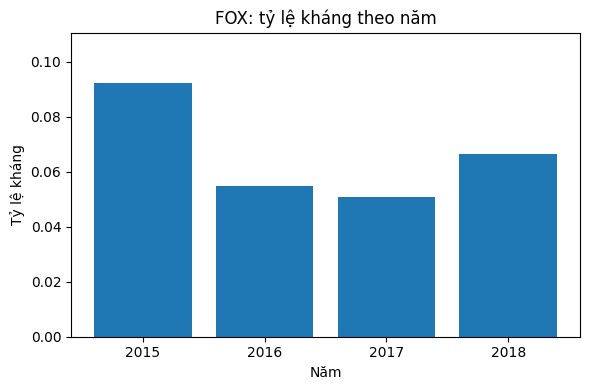

In [15]:
# =========================
# 14. Thống kê phân bố nhãn theo năm
# =========================

year_dist_rows = []

for drug in DRUGS:
    _, y = ready_data[drug]
    idx_year, years = get_year_filtered_index(y)
    y_use = y.loc[idx_year]
    years_use = years.loc[idx_year]

    for year in sorted(years_use.unique()):
        idx = years_use.index[years_use == year]
        yy = y_use.loc[idx]
        year_dist_rows.append({
            "drug": drug,
            "year": int(year),
            "n": len(yy),
            "n_resistant": int(yy.sum()),
            "resistant_rate": float(yy.mean()) if len(yy) else np.nan,
        })

year_dist_df = pd.DataFrame(year_dist_rows)
display(year_dist_df)

year_dist_df.to_csv(OUT_DIR / "label_distribution_by_year.csv", index=False)

# Vẽ nhanh tỷ lệ kháng theo năm.
for drug in DRUGS:
    sub = year_dist_df[year_dist_df["drug"] == drug]
    plt.figure(figsize=(6, 4))
    plt.bar(sub["year"].astype(str), sub["resistant_rate"])
    plt.title(f"{drug}: tỷ lệ kháng theo năm")
    plt.xlabel("Năm")
    plt.ylabel("Tỷ lệ kháng")
    plt.ylim(0, max(0.05, sub["resistant_rate"].max() * 1.2))
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{drug}_resistant_rate_by_year.png", dpi=200)
    plt.show()

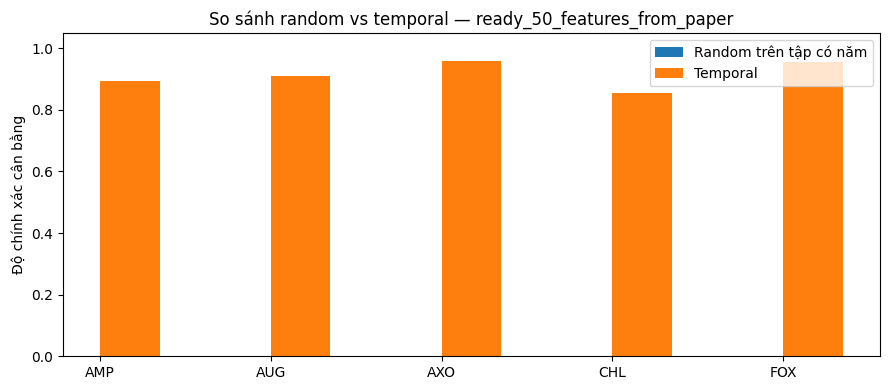

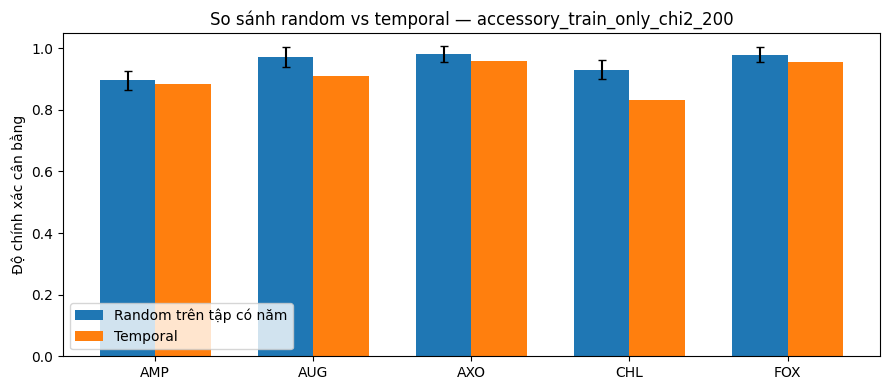

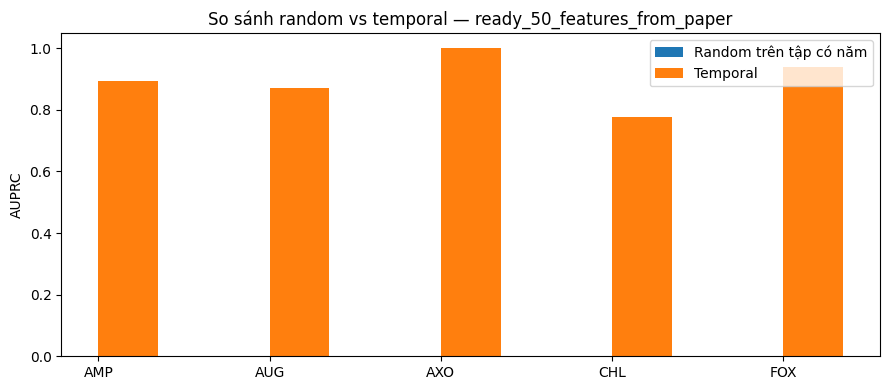

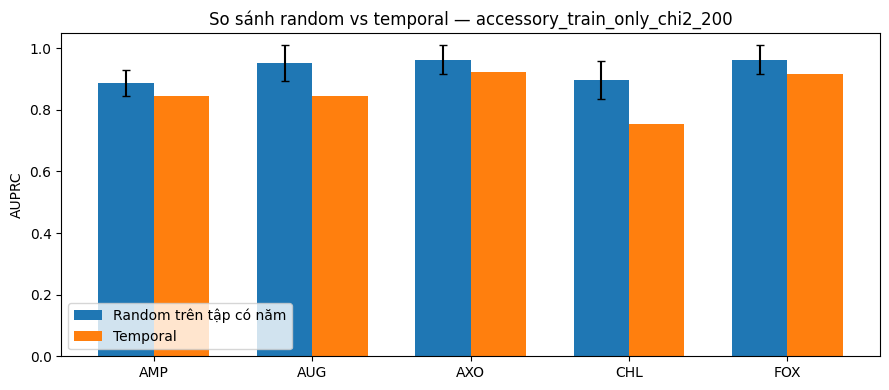

In [16]:
# =========================
# 15. Vẽ biểu đồ temporal vs random
# =========================

# Biểu đồ balanced accuracy.
for setting in comparison_df["setting"].unique():
    sub = comparison_df[comparison_df["setting"] == setting].copy()
    if sub.empty:
        continue

    x = np.arange(len(sub))
    width = 0.35

    plt.figure(figsize=(9, 4))
    plt.bar(x - width/2, sub["random_balanced_accuracy_mean"], width, yerr=sub["random_balanced_accuracy_std"], capsize=3, label="Random trên tập có năm")
    plt.bar(x + width/2, sub["balanced_accuracy"], width, label="Temporal")
    plt.xticks(x, sub["drug"])
    plt.ylim(0, 1.05)
    plt.ylabel("Độ chính xác cân bằng")
    plt.title(f"So sánh random vs temporal — {setting}")
    plt.legend()
    plt.tight_layout()
    fname = OUT_DIR / f"random_vs_temporal_balacc_{setting}.png"
    plt.savefig(fname, dpi=200)
    plt.show()

# Biểu đồ AUPRC.
for setting in comparison_df["setting"].unique():
    sub = comparison_df[comparison_df["setting"] == setting].copy()
    if sub.empty:
        continue

    x = np.arange(len(sub))
    width = 0.35

    plt.figure(figsize=(9, 4))
    plt.bar(x - width/2, sub["random_auprc_mean"], width, yerr=sub["random_auprc_std"], capsize=3, label="Random trên tập có năm")
    plt.bar(x + width/2, sub["auprc"], width, label="Temporal")
    plt.xticks(x, sub["drug"])
    plt.ylim(0, 1.05)
    plt.ylabel("AUPRC")
    plt.title(f"So sánh random vs temporal — {setting}")
    plt.legend()
    plt.tight_layout()
    fname = OUT_DIR / f"random_vs_temporal_auprc_{setting}.png"
    plt.savefig(fname, dpi=200)
    plt.show()

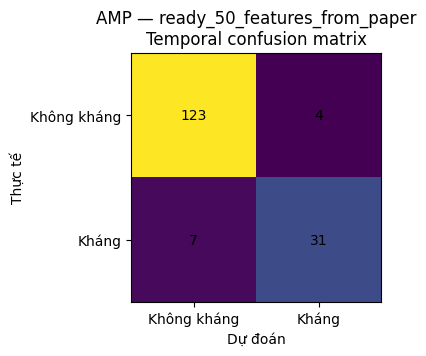

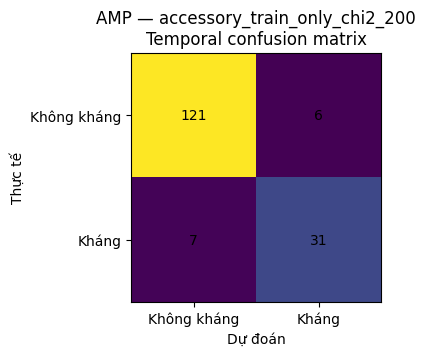

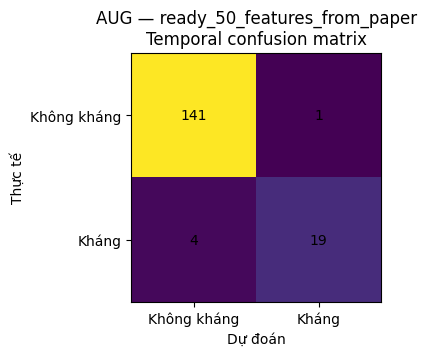

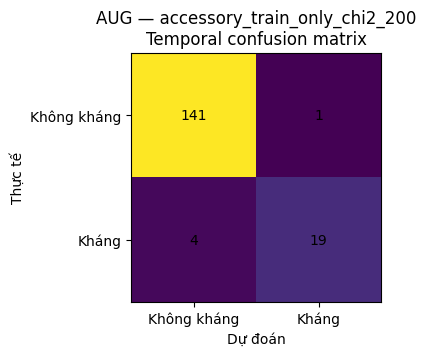

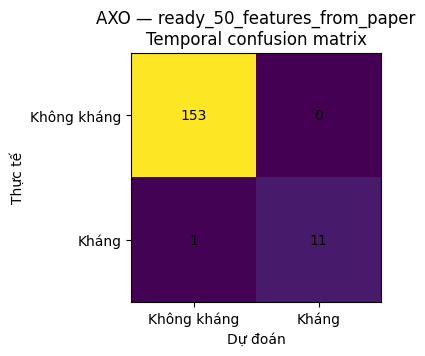

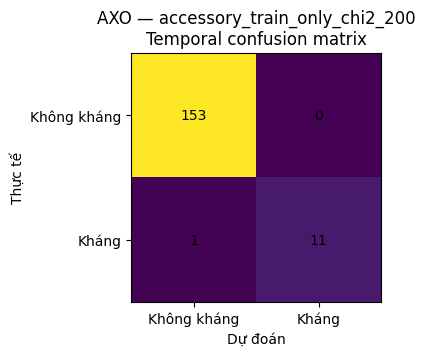

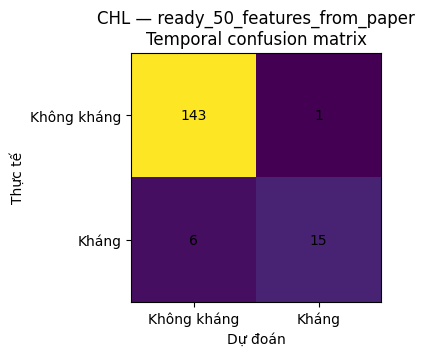

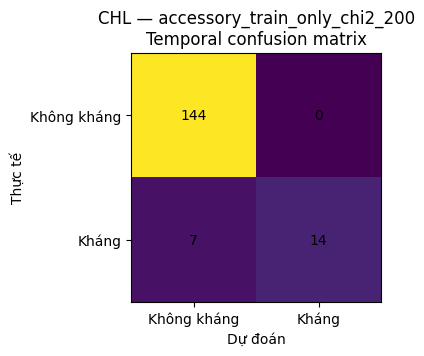

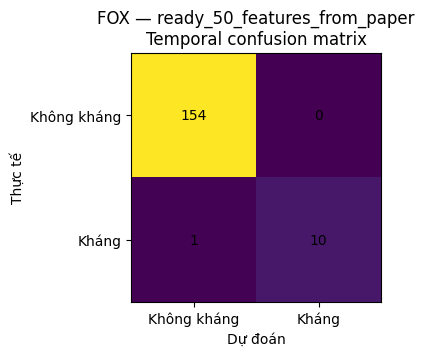

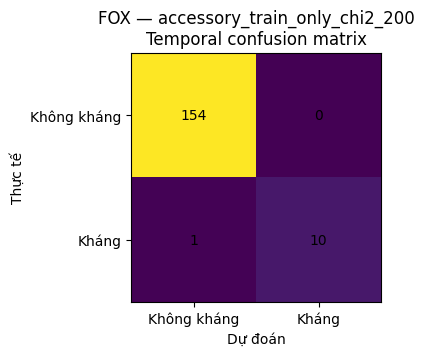

,drug,setting,tn,fp,fn,tp,test_resistant,detected_resistant
0,AMP,ready_50_features_from_paper,123,4,7,31,38,31
1,AMP,accessory_train_only_chi2_200,121,6,7,31,38,31
2,AUG,ready_50_features_from_paper,141,1,4,19,23,19
3,AUG,accessory_train_only_chi2_200,141,1,4,19,23,19
4,AXO,ready_50_features_from_paper,153,0,1,11,12,11
5,AXO,accessory_train_only_chi2_200,153,0,1,11,12,11
6,CHL,ready_50_features_from_paper,143,1,6,15,21,15
7,CHL,accessory_train_only_chi2_200,144,0,7,14,21,14
8,FOX,ready_50_features_from_paper,154,0,1,10,11,10
9,FOX,accessory_train_only_chi2_200,154,0,1,10,11,10


In [17]:
# =========================
# 16. Ma trận nhầm lẫn temporal
# =========================

cm_rows = []

for (drug, setting), pack in temporal_pred_packs.items():
    cm = pack["cm"]
    tn, fp, fn, tp = cm.ravel()
    cm_rows.append({
        "drug": drug,
        "setting": setting,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "test_resistant": int(fn + tp),
        "detected_resistant": int(tp),
    })

    plt.figure(figsize=(4, 4))
    plt.imshow(cm)
    plt.title(f"{drug} — {setting}\nTemporal confusion matrix")
    plt.xticks([0, 1], ["Không kháng", "Kháng"])
    plt.yticks([0, 1], ["Không kháng", "Kháng"])
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"cm_temporal_{drug}_{setting}.png", dpi=200)
    plt.show()

cm_df = pd.DataFrame(cm_rows)
display(cm_df)
cm_df.to_csv(OUT_DIR / "temporal_confusion_matrices.csv", index=False)

In [ ]:
# =========================
# 17. Kết luận
# =========================

lines = []
lines.append("# KẾT LUẬN TỰ ĐỘNG — Direction D temporal split có sanity check\n")

lines.append("## 1. Kiểm tra dữ liệu theo năm\n")
n_total = len(labels_meta)
n_missing_year = int(labels_meta["year_numeric"].isna().sum())
n_has_year = n_total - n_missing_year
lines.append(f"- Tổng số mẫu metadata: {n_total}.")
lines.append(f"- Số mẫu có năm: {n_has_year}.")
lines.append(f"- Số mẫu thiếu năm: {n_missing_year}.")
lines.append("")

lines.append("## 2. Sanity check bằng ready 50 features\n")
for drug in DRUGS:
    sub_all = ready_random_all_df[ready_random_all_df["drug"] == drug]
    sub_year = ready_random_year_df[ready_random_year_df["drug"] == drug]
    if len(sub_all) and len(sub_year):
        lines.append(
            f"- {drug}: ready 50 random toàn bộ = {sub_all['balanced_accuracy'].mean():.3f} ± {sub_all['balanced_accuracy'].std():.3f}; "
            f"ready 50 random tập có năm = {sub_year['balanced_accuracy'].mean():.3f} ± {sub_year['balanced_accuracy'].std():.3f}."
        )
lines.append("")
lines.append("Nếu ready 50 random trên tập có năm vẫn cao, thì căn hàng giữa nhãn và data/csv có khả năng ổn. Nếu nó tụt gần 0.5, cần nghi ngờ tập có năm hoặc căn hàng dữ liệu.")

lines.append("\n## 3. Temporal split\n")
for _, r in temporal_df.iterrows():
    lines.append(
        f"- {r['drug']} | {r['setting']}: train {int(r['train_year_min'])}-{int(r['train_year_max'])}, "
        f"test {int(r['test_year_min'])}-{int(r['test_year_max'])}, "
        f"balanced accuracy = {r['balanced_accuracy']:.3f}, AUPRC = {r['auprc']:.3f}, "
        f"test resistant = {int(r['test_pos'])}."
    )

lines.append("\n## 4. So sánh temporal với random trên cùng tập có năm\n")
for _, r in comparison_df.iterrows():
    lines.append(
        f"- {r['drug']} | {r['setting']}: temporal - random balanced accuracy = "
        f"{r['delta_temporal_minus_random_balacc']:.3f}; temporal - random AUPRC = {r['delta_temporal_minus_random_auprc']:.3f}."
    )

lines.append("\n## 5. Cách diễn giải\n")
lines.append("- Nếu random trên tập có năm cao nhưng temporal thấp, có thể kết luận temporal split khó hơn random split và mô hình gặp vấn đề khi dự đoán năm mới.")
lines.append("- Nếu cả random trên tập có năm và temporal đều thấp, cần kiểm tra thêm việc căn hàng dữ liệu hoặc tập có năm có phân bố khác thường.")
lines.append("- Kết quả temporal nên được dùng như kiểm tra thực tế cho bài toán giám sát, không thay thế hoàn toàn A/B/C.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUT_DIR / "AUTO_CONCLUSION_DIRECTION_D_SANITY.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)

# KẾT LUẬN TỰ ĐỘNG — Direction D temporal split có sanity check

## 1. Kiểm tra dữ liệu theo năm

- Tổng số mẫu metadata: 1167.
- Số mẫu có năm: 737.
- Số mẫu thiếu năm: 430.

## 2. Sanity check bằng ready 50 features

- AMP: ready 50 random toàn bộ = 0.949 ± 0.010; ready 50 random tập có năm = 0.936 ± 0.019.
- AUG: ready 50 random toàn bộ = 0.962 ± 0.019; ready 50 random tập có năm = 0.961 ± 0.025.
- AXO: ready 50 random toàn bộ = 0.981 ± 0.025; ready 50 random tập có năm = 0.980 ± 0.026.
- CHL: ready 50 random toàn bộ = 0.927 ± 0.033; ready 50 random tập có năm = 0.938 ± 0.028.
- FOX: ready 50 random toàn bộ = 0.952 ± 0.037; ready 50 random tập có năm = 0.974 ± 0.035.

Nếu ready 50 random trên tập có năm vẫn cao, thì căn hàng giữa nhãn và data/csv có khả năng ổn. Nếu nó tụt gần 0.5, cần nghi ngờ tập có năm hoặc căn hàng dữ liệu.

## 3. Temporal split

- AMP | ready_50_features_from_paper: train 2015-2017, test 2018-2018, balanced accuracy = 0.892, AUPRC = 0.893, test resistant = 38.


In [ ]:
# =========================
# 18. zip
# =========================

zip_path = BASE_DIR / "salmonella_direction_D_sanity_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for p in OUT_DIR.rglob("*"):
        if p.is_file():
            z.write(p, arcname=str(p.relative_to(OUT_DIR)))

print("Đã nén kết quả:", zip_path)

try:
    from google.colab import files
    print("Bạn có thể tải bằng:")
    print(f"files.download('{zip_path}')")
except Exception:
    pass

Đã nén kết quả: /content/salmonella_direction_D_sanity/salmonella_direction_D_sanity_outputs.zip
Bạn có thể tải bằng:
files.download('/content/salmonella_direction_D_sanity/salmonella_direction_D_sanity_outputs.zip')
